# Dota 2 Counter Picker -- main

- analyzes enemy team composition 
- get hero recommendations based on historical WRs

## Steps:
* Find heroes with high win rates against enemy picks
* Filter by minimum sample size for reliability
* View detailed matchup statistics

In [0]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import base64
import io
from urllib.request import urlopen, Request
from PIL import Image

In [0]:
def get_steam_hero_url(hero_name):
    hero_slug = hero_name.lower().replace("'", "").replace("-", "").replace(" ", "_")
    
    special_cases = {
        "natures_prophet": "furion", "wraith_king": "skeleton_king", "timbersaw": "shredder",
        "clockwerk": "rattletrap", "outworld_destroyer": "obsidian_destroyer", "necrophos": "necrolyte",
        "windranger": "windrunner", "zeus": "zuus", "underlord": "abyssal_underlord",
        "anti_mage": "antimage", "lifestealer": "life_stealer", "doom": "doom_bringer",
        "treant_protector": "treant", "centaur_warrunner": "centaur"
    }
    
    if hero_slug in special_cases:
        hero_slug = special_cases[hero_slug]
    
    return f"https://cdn.cloudflare.steamstatic.com/apps/dota2/images/dota_react/heroes/{hero_slug}.png"

def display_hero_grid_steam(hero_names, heroes_df, limit=12):
    if hero_names:
        heroes = heroes_df.filter(F.col("name").isin(hero_names)).collect()
    else:
        heroes = heroes_df.limit(limit).collect()
    
    html = '<div style="display: flex; flex-wrap: wrap; gap: 15px; justify-content: center;">' 
    
    for hero in heroes:
        try:
            img_url = get_steam_hero_url(hero.name)
            req = Request(img_url, headers={'User-Agent': 'Mozilla/5.0'})
            response = urlopen(req)
            img_data = response.read()
            
            img = Image.open(io.BytesIO(img_data))
            
            if img.mode in ('RGBA', 'LA', 'P'):
                background = Image.new('RGB', img.size, (255, 255, 255))
                if img.mode == 'P':
                    img = img.convert('RGBA')
                background.paste(img, mask=img.split()[-1] if img.mode == 'RGBA' else None)
                img = background
            elif img.mode != 'RGB':
                img = img.convert('RGB')
            
            buffer = io.BytesIO()
            img.save(buffer, format='JPEG', quality=95)
            img_base64 = base64.b64encode(buffer.getvalue()).decode('utf-8')
            
            html += f"""
            <div style="border: 3px solid #333; padding: 12px; text-align: center; width: 200px; 
                        background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); border-radius: 8px;
                        box-shadow: 0 4px 8px rgba(0,0,0,0.3);">
                <img src="data:image/jpeg;base64,{img_base64}" width="150" style="border-radius: 5px; border: 2px solid white;">
                <h4 style="margin: 8px 0; color: white; text-shadow: 1px 1px 2px rgba(0,0,0,0.5);">{hero.name}</h4>
                <p style="font-size: 13px; color: #ffd700; margin: 4px 0; font-weight: bold;">{hero.primary_attr.upper()}</p>
                <p style="font-size: 11px; color: #ddd; margin: 0;">{hero.roles}</p>
            </div>
            """
        except Exception as e:
            print(f"Failed to load {hero.name}: {e}")
    
    html += '</div>'
    displayHTML(html)

def get_best_counters(enemy_hero_names, heroes_df, matchups_df, top_n=10):
    enemy_ids = [
        row.hero_id
        for row in heroes_df.filter(F.col("name").isin(enemy_hero_names))
        .select("hero_id")
        .collect()
    ]

    if not enemy_ids:
        print("No matching enemy heroes found.")
        return None

    filtered_matchups = matchups_df.filter(
        F.col("against_hero_id").isin(enemy_ids)
    )

    counter_rankings = (
        filtered_matchups.groupby("hero_id")
        .agg(
            F.avg("win_rate").alias("avg_win_rate_vs_enemies"),
            F.sum("games_played").alias("total_games_sample"),
        )
        .filter(
            F.col("total_games_sample") > 500
        )
        .join(heroes_df, "hero_id")
        .filter(~F.col("name").isin(enemy_hero_names))
        .select(
            "name",
            "primary_attr",
            "roles",
            F.round("avg_win_rate_vs_enemies", 2).alias("win_rate_pct"),
            "total_games_sample",
        )
        .orderBy(F.desc("avg_win_rate_vs_enemies"))
        .limit(top_n)
    )

    return counter_rankings

In [0]:
heroes_df = spark.table("dota_heroes")
matchups_df = spark.table("dota_hero_matchups")

In [0]:
# enemy team here
enemy_team = ["Phantom Assassin", "Necrophos", "Invoker", "Venomancer"]

print("Enemy Team:")
for hero in enemy_team:
    print(f"  • {hero}")


# counter recommendations
counters_df = get_best_counters(
    enemy_hero_names=enemy_team,
    heroes_df=heroes_df,
    matchups_df=matchups_df,
    top_n=10
)

print("\n Top 10 Counter Heroes:")
display(counters_df)

Enemy Team:
  • Phantom Assassin
  • Necrophos
  • Invoker
  • Venomancer

 Top 10 Counter Heroes:


name,primary_attr,roles,win_rate_pct,total_games_sample
Hoodwink,agi,"Support, Nuker, Escape, Disabler",55.15,535
Rubick,int,"Support, Disabler, Nuker",54.89,866
Queen of Pain,int,"Carry, Nuker, Escape",53.95,573
Pudge,str,"Disabler, Initiator, Durable, Nuker",53.32,532
Windranger,all,"Carry, Support, Disabler, Escape, Nuker",53.28,516
Snapfire,all,"Support, Nuker, Disabler, Escape",52.98,624
Disruptor,int,"Support, Disabler, Nuker, Initiator",50.9,645
Lion,int,"Support, Disabler, Nuker, Initiator",50.23,607
Shadow Fiend,agi,"Carry, Nuker",49.53,881
Jakiro,int,"Support, Nuker, Pusher, Disabler",49.04,563


Top 5 Counter Heroes:

Failed to load Queen of Pain: HTTP Error 404: Not Found


Pudge 
 STR 
 Disabler, Initiator, Durable, Nuker 
 
 
 
 
 Windranger 
 ALL 
 Carry, Support, Disabler, Escape, Nuker 
 
 
 
 
 Rubick 
 INT 
 Support, Disabler, Nuker 
 
 
 
 
 Hoodwink 
 AGI 
 Support, Nuker, Escape, Disabler
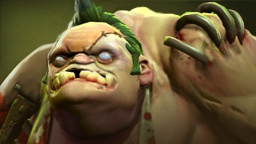
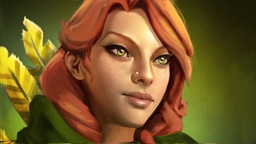
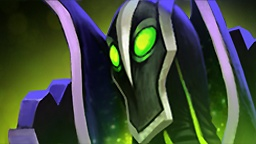
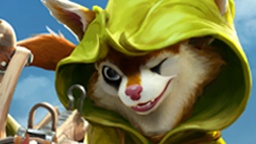

In [0]:
# top counters with images --> small feature still in progress (only playing with it for now)
counter_heroes_num = 5
top_counter_names = [row.name for row in counters_df.limit(counter_heroes_num).collect()]

print(f"Top {counter_heroes_num} Counter Heroes:\n")
display_hero_grid_steam(top_counter_names, heroes_df)

In [0]:
my_enemy_team = [
    "Anti-Mage",
    "Axe", 
    "Crystal Maiden",
    "Pudge"
]

counters = get_best_counters(
    enemy_hero_names=my_enemy_team,
    heroes_df=heroes_df,
    matchups_df=matchups_df,
    top_n=15
)

if counters:
    display(counters)

name,primary_attr,roles,win_rate_pct,total_games_sample
Ember Spirit,agi,"Carry, Escape, Nuker, Disabler, Initiator",56.88,517
Spirit Breaker,str,"Carry, Initiator, Disabler, Durable, Escape",56.2,559
Hoodwink,agi,"Support, Nuker, Escape, Disabler",53.5,659
Abaddon,all,"Support, Carry, Durable",53.1,558
Snapfire,all,"Support, Nuker, Disabler, Escape",52.8,1068
Timbersaw,str,"Nuker, Durable, Escape",52.62,539
Jakiro,int,"Support, Nuker, Pusher, Disabler",52.35,944
Tiny,str,"Carry, Nuker, Pusher, Initiator, Durable, Disabler",51.99,659
Dawnbreaker,str,"Carry, Durable",51.94,603
Lion,int,"Support, Disabler, Nuker, Initiator",51.89,1001
